In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalize images (0–1 range)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


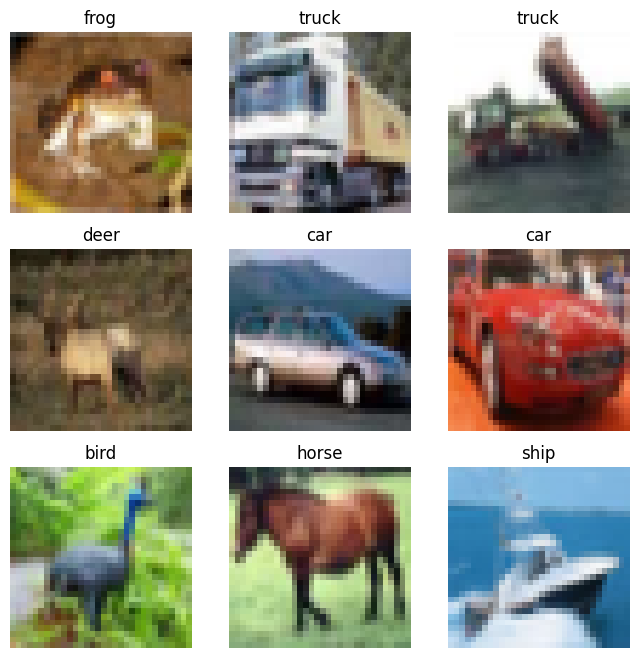

In [3]:
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.show()

In [4]:
def create_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [5]:
model_no_aug = create_model()

history_no_aug = model_no_aug.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 45ms/step - accuracy: 0.4536 - loss: 1.5103 - val_accuracy: 0.5423 - val_loss: 1.2993
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.5953 - loss: 1.1518 - val_accuracy: 0.6185 - val_loss: 1.0972
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6468 - loss: 1.0139 - val_accuracy: 0.6467 - val_loss: 1.0214
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6758 - loss: 0.9355 - val_accuracy: 0.6760 - val_loss: 0.9540
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6968 - loss: 0.8743 - val_accuracy: 0.6758 - val_loss: 0.9484


In [6]:
datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(X_train)

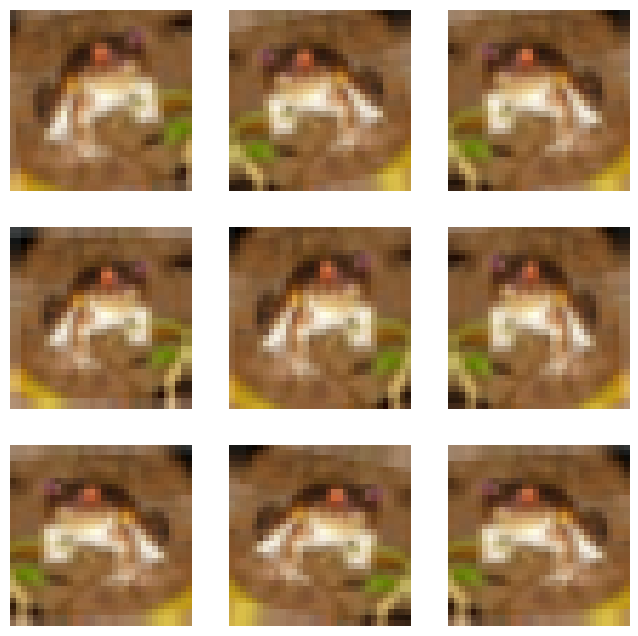

In [7]:
sample_image = X_train[0]

sample_image = np.expand_dims(sample_image, 0)

plt.figure(figsize=(8,8))

for i, batch in enumerate(datagen.flow(sample_image, batch_size=1)):
    plt.subplot(3,3,i+1)
    plt.imshow(batch[0])
    plt.axis('off')

    if i == 8:
        break

plt.show()

In [8]:
model_aug = create_model()

history_aug = model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 60ms/step - accuracy: 0.4354 - loss: 1.5552 - val_accuracy: 0.5298 - val_loss: 1.2971
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.5575 - loss: 1.2487 - val_accuracy: 0.6165 - val_loss: 1.1183
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.6062 - loss: 1.1288 - val_accuracy: 0.6271 - val_loss: 1.0729
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.6273 - loss: 1.0693 - val_accuracy: 0.6459 - val_loss: 1.0401
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 60ms/step - accuracy: 0.6467 - loss: 1.0186 - val_accuracy: 0.6495 - val_loss: 0.9927


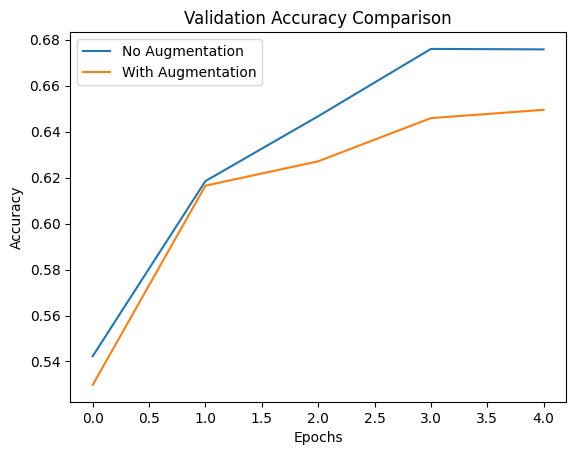

In [9]:
plt.plot(history_no_aug.history['val_accuracy'], label='No Augmentation')
plt.plot(history_aug.history['val_accuracy'], label='With Augmentation')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


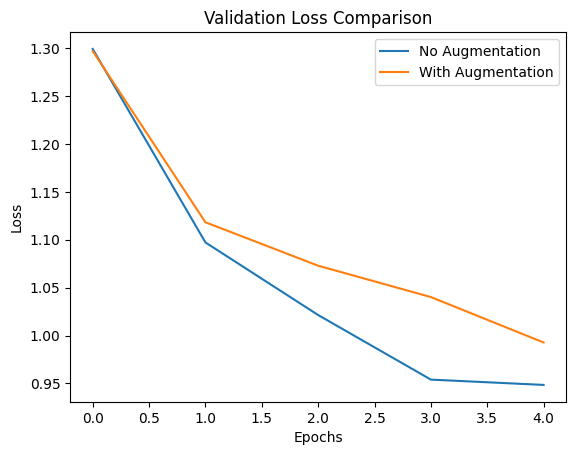

In [10]:
plt.plot(history_no_aug.history['val_loss'], label='No Augmentation')
plt.plot(history_aug.history['val_loss'], label='With Augmentation')

plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
loss_no_aug, acc_no_aug = model_no_aug.evaluate(X_test, y_test)
loss_aug, acc_aug = model_aug.evaluate(X_test, y_test)

print("No Augmentation Accuracy:", acc_no_aug)
print("With Augmentation Accuracy:", acc_aug)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6758 - loss: 0.9484
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6495 - loss: 0.9927
No Augmentation Accuracy: 0.6758000254631042
With Augmentation Accuracy: 0.6495000123977661
